In [9]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestRegressor

# Col names that are always the same, given as default vals in functions
metric_cols = [
    "rate",
    "func_reduction_density_mean",
    "func_reduction_density_std",
    "uc_depth_mean",
    "uc_depth_std",
    "uc_modularity",
]
energy_col = "energy_total_mean"
accuracy_col = "accuracy_error"


def compute_accuracy_error(df, baseline, accuracy_cols):
    """Compute one normalized average error"""

    relative_errors = []

    for col in accuracy_cols:
        baseline_value = baseline[col]
        # ensure not diving by 0
        if baseline_value == 0:
            denominator = 1e-12
        else:
            denominator = abs(baseline_value)

        relative_error = (df[col] - baseline_value).abs() / denominator

        relative_errors.append(relative_error)

    df["accuracy_error"] = sum(relative_errors) / len(relative_errors)

    return df


def load_and_prep(path, accuracy_cols):
    """Load aggregated results, calculate accuracy error, and split failures."""

    df = pd.read_csv(path)

    # Get baseline row
    baseline_rows = df[df["variant_id"] == "baseline"]

    baseline = baseline_rows.iloc[0]

    # Remove baseline
    df = df[df["variant_id"] != "baseline"].copy()

    # Failed if any evaluator output is missing
    failed = df[accuracy_cols].isna().any(axis=1)

    failure = df[failed].copy()
    success = df[~failed].copy()

    # Calculate single accuracy measure
    success = compute_accuracy_error(
        success,
        baseline,
        accuracy_cols,
    )

    return {
        "success": success,
        "failure": failure,
        "baseline": baseline,
    }


####################################################################
# See if there are any correlations between metrics and accuracy/energy
def calculate_correlation(
    df,
    energy_col=energy_col,
    accuracy_col=accuracy_col,
    metric_cols=metric_cols,
    alpha=0.05,
):
    """Correlation table between metrics and energy/accuracy"""
    energy_correlations = []
    accuracy_correlations = []

    # energy
    for metric in metric_cols:
        # remove empty
        metric_energy = df[[metric, energy_col]].dropna()
        metric_accuracy = df[[metric, accuracy_col]].dropna()
        # use spearmans rank because can't guarantee results are parametric
        e_stat, e_p_val = stats.spearmanr(
            metric_energy[metric], metric_energy[energy_col]
        )
        energy_correlations.append(
            {
                "metric": metric,
                "correlation": e_stat,
                "p_value": e_p_val,
                "is_significant": e_p_val < alpha,
            }
        )
        a_stat, a_p_val = stats.spearmanr(
            metric_accuracy[metric], metric_accuracy[accuracy_col]
        )
        accuracy_correlations.append(
            {
                "metric": metric,
                "correlation": a_stat,
                "p_value": a_p_val,
                "is_significant": a_p_val < alpha,
            }
        )

    return {
        "energy": pd.DataFrame(energy_correlations)
        .set_index("metric")
        .sort_values("p_value"),
        "accuracy": pd.DataFrame(accuracy_correlations)
        .set_index("metric")
        .sort_values("p_value"),
    }


####################################################################
# Work out if there are any differences in the metric vals for failed output vs successful output


def compare_failure_vs_success(
    success_df, failure_df, metric_cols=metric_cols, alpha=0.05
):
    results = []
    for metric in metric_cols:
        metric_success = success_df[metric].dropna()
        metric_failed = failure_df[metric].dropna()

        # mann-whitney non parametric
        stat, p_val = stats.mannwhitneyu(metric_success, metric_failed)
        results.append(
            {
                "metric": metric,
                "success_mean": round(metric_success.mean(), 3),
                "failure_mean": round(metric_failed.mean(), 3),
                "p_value": p_val,
                "is_significant": p_val < alpha,
            }
        )
    return pd.DataFrame(results).set_index("p_value")


####################################################################
# Work out the influence of the metrics on the energy measurement and the accuracy


def determine_importance(
    df, measure_col, metric_cols=metric_cols, n_estimators=400, random_state=123
):
    """Determines the importance of each metric on a another column"""
    cleaned = df.dropna(subset=[measure_col])
    X = cleaned[metric_cols].fillna(0)
    y = cleaned[measure_col]
    regressor = RandomForestRegressor(
        n_estimators=n_estimators, random_state=random_state
    )
    regressor.fit(X, y)
    return pd.Series(
        regressor.feature_importances_, index=metric_cols, name=measure_col
    ).round(3)


def determine_importance_energy_accuracy(
    df,
    energy_col=energy_col,
    accuracy_col=accuracy_col,
    metric_cols=metric_cols,
    n_estimators=400,
    random_state=123,
):
    """Calls determine importance for energy and accuracy"""

    return pd.concat(
        [
            determine_importance(
                df,
                energy_col,
                metric_cols=metric_cols,
                n_estimators=n_estimators,
                random_state=random_state,
            ),
            determine_importance(
                df,
                accuracy_col,
                metric_cols=metric_cols,
                n_estimators=n_estimators,
                random_state=random_state,
            ),
        ],
        axis=1,
    ).rename(
        columns={
            energy_col: "energy",
            accuracy_col: "accuracy",
        }
    )


####################################################################
# PLOTS


def plot_metric_importance(
    importances, title="Metric influence on energy and accuracy usage"
):
    fig, ax = plt.subplots(figsize=(6, 4))
    importances.plot.barh(ax=ax)
    ax.set_xlabel("Random forest importance")
    ax.legend(importances.columns, bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_title(title)
    plt.tight_layout()
    return fig


def plot_tradeoff(
    success, accuracy_col=accuracy_col, energy_col=energy_col, color_by="rate"
):
    """Accuracy, energy trade-off"""
    n_plots = len(success.columns)
    n_cols = 3
    fig, ax = plt.subplots(figsize=(6, 5))
    scatter = ax.scatter(
        success[energy_col],
        success[accuracy_col],
        c=success[color_by],
        cmap="viridis",
    )
    fig.colorbar(scatter, ax=ax, label=color_by)
    ax.set_xlabel("Total energy consumed (J)")
    ax.set_ylabel(f"Normalised output error relative to the baseline")
    ax.set_title(f"Energy vs accuracy tradeoff")
    plt.tight_layout()
    plt.show()


def plot_metric_energy(
    success, accuracy_col=accuracy_col, energy_col=energy_col, metric_cols=metric_cols
):
    n_cols = 3
    n_rows = math.ceil(len(metric_cols) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
    )

    axes = axes.flatten()
    for ax, metric in zip(axes, metric_cols):
        ax.scatter(
            success[metric],
            success["energy_total_mean"],
            alpha=0.6,
        )
        ax.set_xlabel(metric)
        ax.set_ylabel("energy_total_mean")
        ax.set_title(f"{metric} vs energy")
    for ax in axes[len(metric_cols) :]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

# TEST SUBJECT

## Config
source_project_name = "test_project"

id = "test-01"

source_file_type = "cpp"

from_type = "fp64"

to_type = "fp32"

reduction_rates = [
    0.1,
    0.3,
    0.5,
    0.7,
    0.9
]

variants_per_rate = 15

repeat_variant = 15

pause_between_variants = 5

repeat_evaluation = 30

base_seed = 12345

execution_timeout = 10

stdin = "2.0 3.0"

/tmp/ipykernel_58841/1776739100.py:106: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  a_stat, a_p_val = stats.spearmanr(
/tmp/ipykernel_58841/1776739100.py:95: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  e_stat, e_p_val = stats.spearmanr(
/tmp/ipykernel_58841/1776739100.py:106: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  a_stat, a_p_val = stats.spearmanr(
/tmp/ipykernel_58841/1776739100.py:95: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  e_stat, e_p_val = stats.spearmanr(
/tmp/ipykernel_58841/1776739100.py:106: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  a_stat, a_p_val = stats.spearmanr(
/tmp/ipykernel_58841/1776739100.py:106: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  a_stat, a_p

Correlations
Energy Correlations
                             correlation   p_value  is_significant
metric                                                            
rate                            0.100601  0.390461           False
uc_depth_mean                  -0.100212  0.392307           False
uc_depth_std                    0.033658  0.774366           False
func_reduction_density_mean          NaN       NaN           False
func_reduction_density_std           NaN       NaN           False
uc_modularity                        NaN       NaN           False
Accuracy Correlations
                             correlation  p_value  is_significant
metric                                                           
rate                                 NaN      NaN           False
func_reduction_density_mean          NaN      NaN           False
func_reduction_density_std           NaN      NaN           False
uc_depth_mean                        NaN      NaN           False
uc_depth_std 

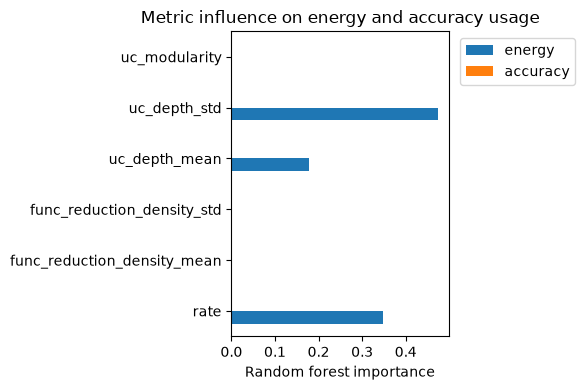

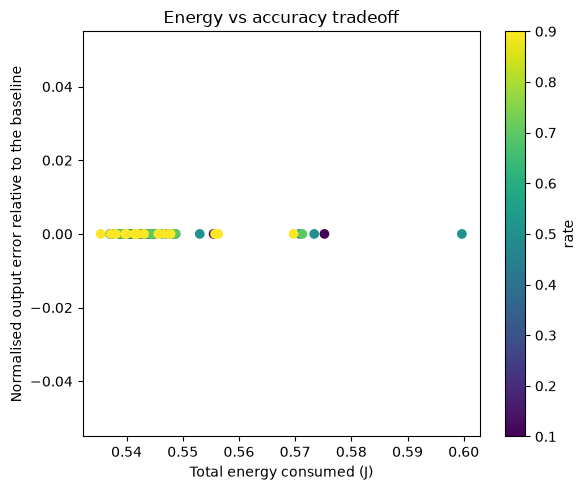

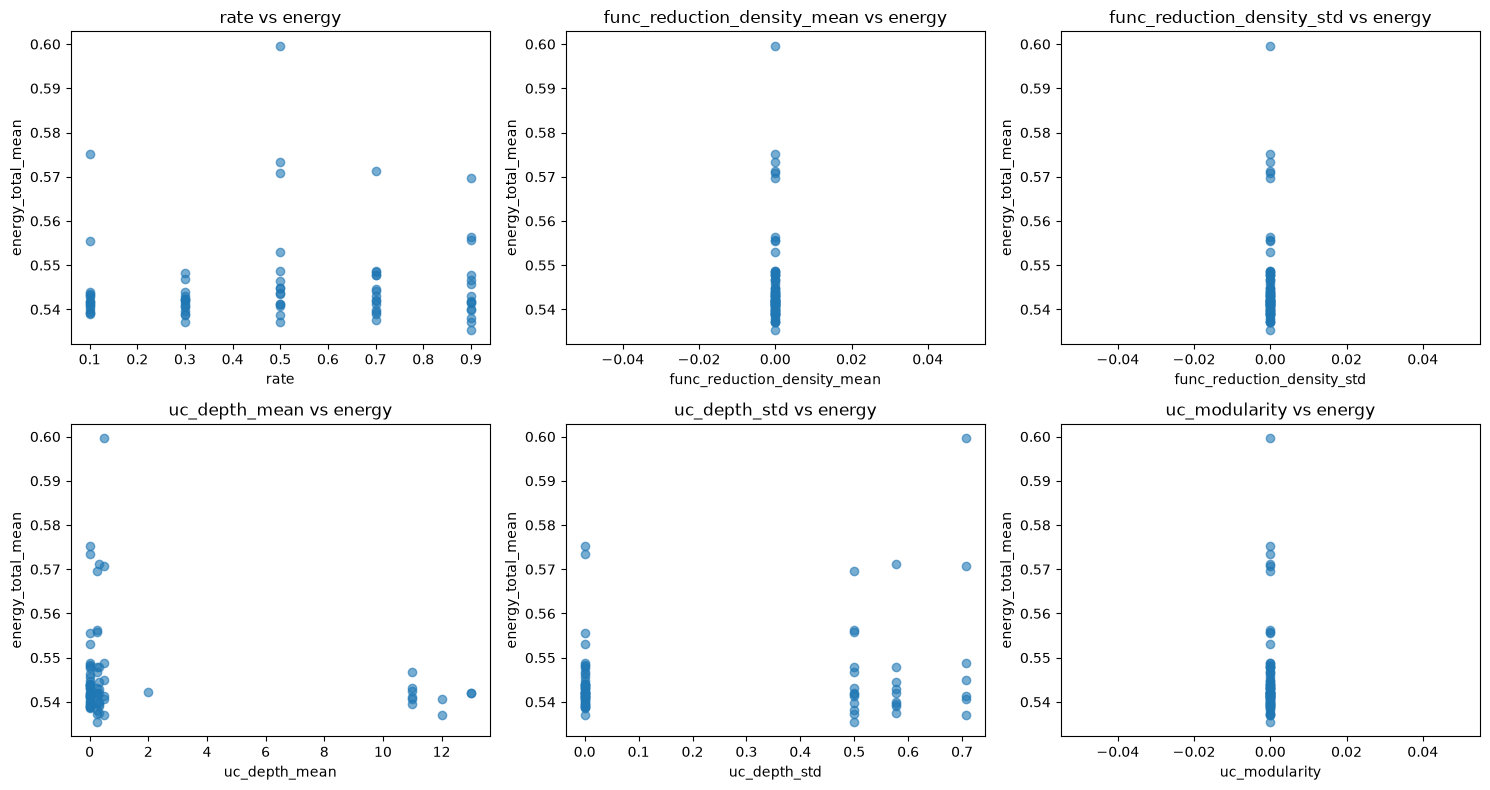

In [10]:
aggregated = "/home/eve/Projects/codebase-approx-variant-sampler/out/experiments/test-01/test-01_aggregated_results.csv"
output_cols = ["result"]

imported = load_and_prep(aggregated, output_cols)

correlations = calculate_correlation(imported["success"])
print("Correlations")
print("Energy Correlations")
print(correlations["energy"])
print("Accuracy Correlations")
print(correlations["accuracy"])

success_failure = compare_failure_vs_success(imported["success"], imported["failure"])
print("Influence on success in output")
print(success_failure)

importances = determine_importance_energy_accuracy(imported["success"])
plot_metric_importance(importances)

plot_tradeoff(imported["success"])

plot_metric_energy(imported["success"])



# LULESH

## Config
source_project_name = "LULESH"

id = "LULESH-04"

source_file_type = "cc"

from_type = "fp64"

to_type = "fp32"

reduction_rates = [
    0.3,
    0.6,
    0.9
]

variants_per_rate = 15

repeat_variant = 1

pause_between_variants = 5

repeat_evaluation = 30

base_seed = 12345

execution_timeout = 21

args = ["-s", "20"]

/tmp/ipykernel_58841/1776739100.py:95: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  e_stat, e_p_val = stats.spearmanr(
/tmp/ipykernel_58841/1776739100.py:106: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  a_stat, a_p_val = stats.spearmanr(
/tmp/ipykernel_58841/1776739100.py:95: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  e_stat, e_p_val = stats.spearmanr(
/tmp/ipykernel_58841/1776739100.py:106: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  a_stat, a_p_val = stats.spearmanr(


Correlations
Energy Correlations
                             correlation   p_value  is_significant
metric                                                            
rate                           -0.639010  0.063924           False
uc_depth_std                    0.150000  0.700094           False
uc_modularity                   0.133333  0.732368           False
uc_depth_mean                   0.050000  0.898353           False
func_reduction_density_mean          NaN       NaN           False
func_reduction_density_std           NaN       NaN           False
Accuracy Correlations
                             correlation   p_value  is_significant
metric                                                            
uc_depth_std                    0.616667  0.076929           False
uc_modularity                   0.583333  0.099186           False
uc_depth_mean                   0.533333  0.139227           False
rate                            0.182574  0.638240           False
func_re

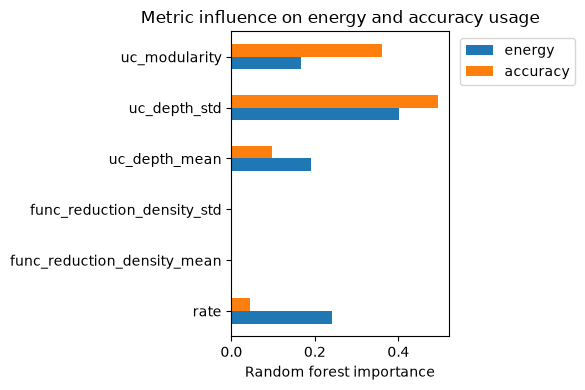

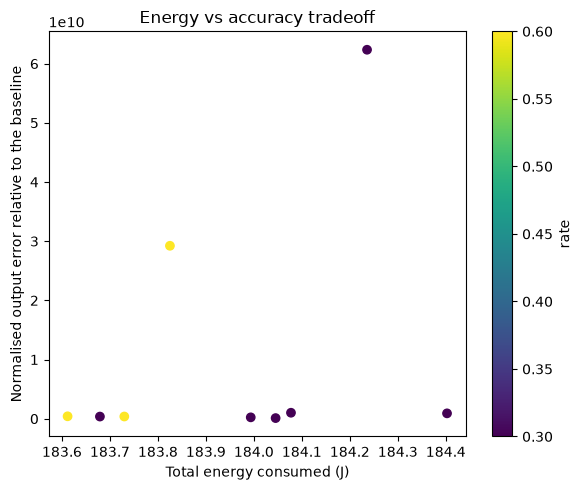

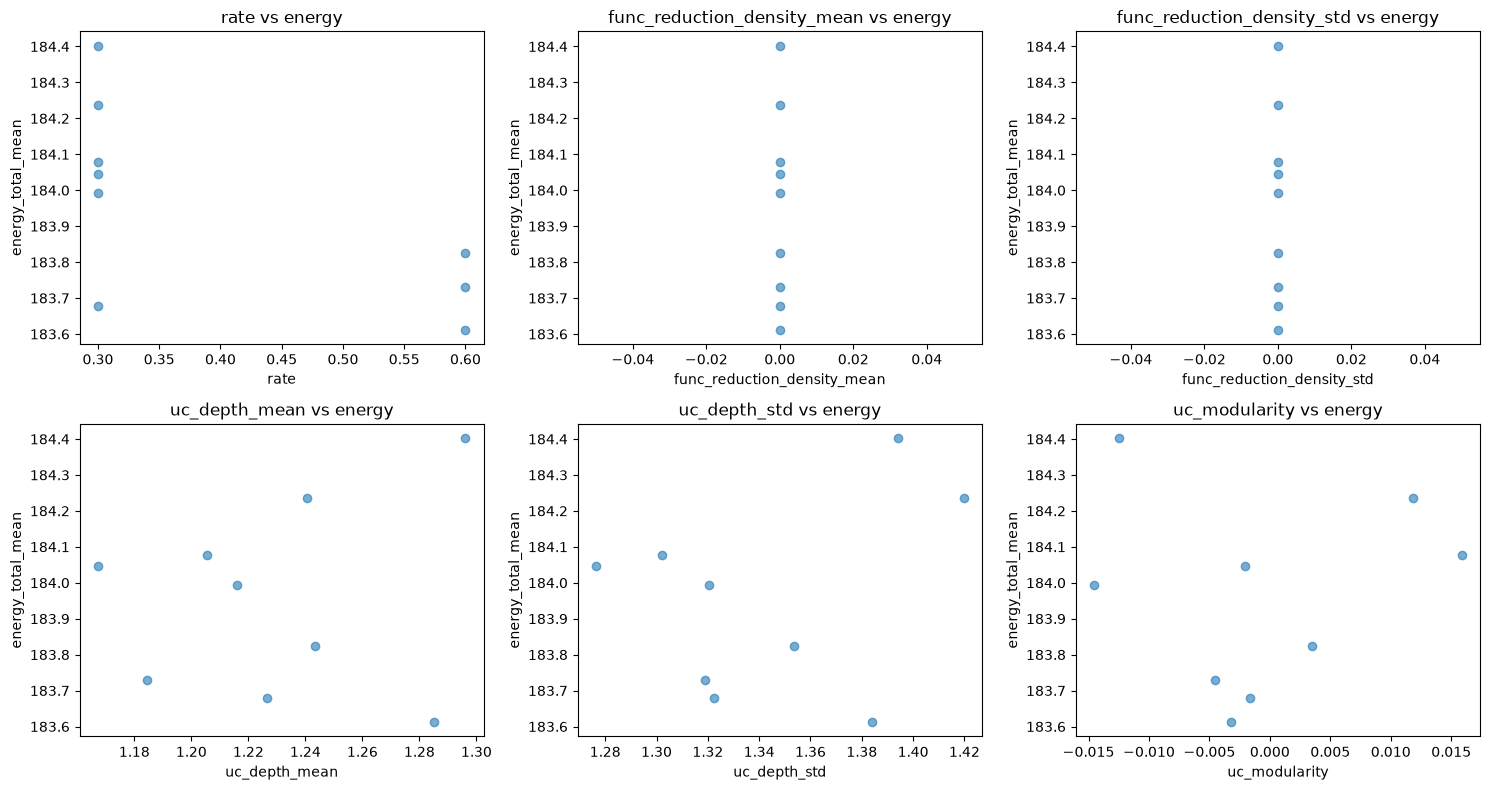

In [11]:
aggregated = "/home/eve/Projects/codebase-approx-variant-sampler/out/experiments/LULESH-04/LULESH-04_aggregated_results.csv"
output_cols = ["max_abs_diff", "total_abs_diff", "max_rel_diff"]

imported = load_and_prep(aggregated, output_cols)

correlations = calculate_correlation(imported["success"])
print("Correlations")
print("Energy Correlations")
print(correlations["energy"])
print("Accuracy Correlations")
print(correlations["accuracy"])

success_failure = compare_failure_vs_success(imported["success"], imported["failure"])
print("Influence on success in output")
print(success_failure)

importances = determine_importance_energy_accuracy(imported["success"])
plot_metric_importance(importances)

plot_tradeoff(imported["success"])

plot_metric_energy(imported["success"])

